In [198]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [199]:
df=pd.read_csv(r'signal_metrics_with_sigQUAL.csv')

DATA INSPECTION

In [200]:
df

,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
0,50:40.0,Anisabad,25.599109,85.137355,-84.274113,47,1.863890,129.122914,3G,0.000000,0.000000,0.000000
1,18:44.9,Boring Road,25.564499,85.088607,-84.643065,58,1.567842,130.536386,3G,0.000000,0.000000,0.000000
2,34:20.9,Rajendra Nagar,25.698981,85.193941,-79.656127,45,1.116387,191.521373,3G,0.000000,0.000000,0.000000
3,40:35.4,Gandhi Maidan,25.470778,85.106450,-85.607373,47,2.171551,194.023024,3G,0.000000,0.000000,0.000000
4,05:33.0,Kumhrar,25.573279,85.158042,-83.978154,44,1.753478,174.957830,3G,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
16824,10:04.6,Ashok Rajpath,25.513184,85.297269,-98.074638,90,1.315881,182.367525,LTE,-98.921721,-107.391454,-98.493889
16825,16:19.1,Danapur,25.706732,85.112217,-90.221943,88,1.034086,184.187310,LTE,-92.392586,-96.749804,-92.434660
16826,22:33.5,Kumhrar,25.706064,85.262218,-88.158025,74,2.473377,179.894750,LTE,-83.235642,-95.165784,-88.222760
16827,47:31.2,Boring Canal Road,25.724624,85.233365,-87.579509,73,2.117080,134.458401,LTE,-87.694985,-92.616868,-84.749607


In [201]:
df.columns

Index(['Timestamp', 'Locality', 'Latitude', 'Longitude',
       'Signal Strength (dBm)', 'Signal Quality (%)', 'Data Throughput (Mbps)',
       'Latency (ms)', 'Network Type', 'BB60C Measurement (dBm)',
       'srsRAN Measurement (dBm)', 'BladeRFxA9 Measurement (dBm)'],
      dtype='str')

In [202]:
# Column name constants

LONGITUDE = "Longitude"
LATITUDE = "Latitude"
NETWORK = "Network Type"
SIGNAL = "Signal Strength (dBm)"
SIGNAL_QUALITY = "Signal Quality (%)"
THROUGHPUT = "Data Throughput (Mbps)"
LATENCY = "Latency (ms)"
BB60C = "BB60C Measurement (dBm)"
SRSRAN = "srsRAN Measurement (dBm)"
BLADERF = "BladeRFxA9 Measurement (dBm)"

cols = [LONGITUDE,LATITUDE,NETWORK,SIGNAL,SIGNAL_QUALITY,THROUGHPUT,LATENCY,BB60C,SRSRAN,BLADERF]

# ORDER = ["3G", "4G", "5G"]
ORDER = ["5G"]

PALETTE = {
    "3G": "lightgreen",
    "4G": "skyblue",
    "LTE": "red",
    "5G": "lightcoral"
}

METRICS = [
    SIGNAL,
    SIGNAL_QUALITY,
    THROUGHPUT,
    LATENCY,
    BB60C,
    SRSRAN,
    BLADERF
]


In [203]:
# column dtypes

df[cols].dtypes

Longitude                       float64
Latitude                        float64
Network Type                        str
Signal Strength (dBm)           float64
Signal Quality (%)                int64
Data Throughput (Mbps)          float64
Latency (ms)                    float64
BB60C Measurement (dBm)         float64
srsRAN Measurement (dBm)        float64
BladeRFxA9 Measurement (dBm)    float64
dtype: object

In [204]:
# memory usage

df[cols].memory_usage(deep=True)

Index                              132
Longitude                       134632
Latitude                        134632
Network Type                    862503
Signal Strength (dBm)           134632
Signal Quality (%)              134632
Data Throughput (Mbps)          134632
Latency (ms)                    134632
BB60C Measurement (dBm)         134632
srsRAN Measurement (dBm)        134632
BladeRFxA9 Measurement (dBm)    134632
dtype: int64

In [205]:
# total memory usage
df[cols].memory_usage(deep=True).sum()

np.int64(2074323)

In [206]:
# examining min and max 

(df
[cols]
.select_dtypes(float)
.describe()
)

,Longitude,Latitude,Signal Strength (dBm),Data Throughput (Mbps),Latency (ms),BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
count,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000
mean,85.137314,25.594796,-90.072484,16.182856,101.313624,-68.820150,-74.439562,-68.819930
std,0.090095,0.089881,5.399368,25.702734,56.010418,40.046739,43.215204,39.996934
min,84.957936,25.414575,-116.942267,1.000423,10.019527,-115.667514,-124.652054,-119.207545
25%,85.064124,25.522858,-93.615962,2.001749,50.320775,-94.021959,-101.249987,-93.749032
50%,85.138149,25.595383,-89.665566,2.997175,100.264318,-89.126942,-96.838442,-89.282746
75%,85.209504,25.667620,-86.145491,9.956314,149.951112,0.000000,0.000000,0.000000
max,85.316994,25.773648,-74.644848,99.985831,199.991081,0.000000,0.000000,0.000000


In [207]:
# converting float64 to float16 
(df[cols]
 .select_dtypes(float)
 .astype('float16')
)

c:\Users\WinUser\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Longitude,Latitude,Signal Strength (dBm),Data Throughput (Mbps),Latency (ms),BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
0,85.1250,25.593750,-84.2500,1.864258,129.125,0.0000,0.0000,0.0000
1,85.0625,25.562500,-84.6250,1.567383,130.500,0.0000,0.0000,0.0000
2,85.1875,25.703125,-79.6250,1.116211,191.500,0.0000,0.0000,0.0000
3,85.1250,25.468750,-85.6250,2.171875,194.000,0.0000,0.0000,0.0000
4,85.1875,25.578125,-84.0000,1.753906,175.000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...
16824,85.3125,25.515625,-98.0625,1.315430,182.375,-98.9375,-107.3750,-98.5000
16825,85.1250,25.703125,-90.2500,1.034180,184.125,-92.3750,-96.7500,-92.4375
16826,85.2500,25.703125,-88.1875,2.472656,179.875,-83.2500,-95.1875,-88.2500
16827,85.2500,25.718750,-87.5625,2.117188,134.500,-87.6875,-92.6250,-84.7500


KPI ANALYSIS

<Axes: xlabel='Network Type', ylabel='Latency (ms)'>

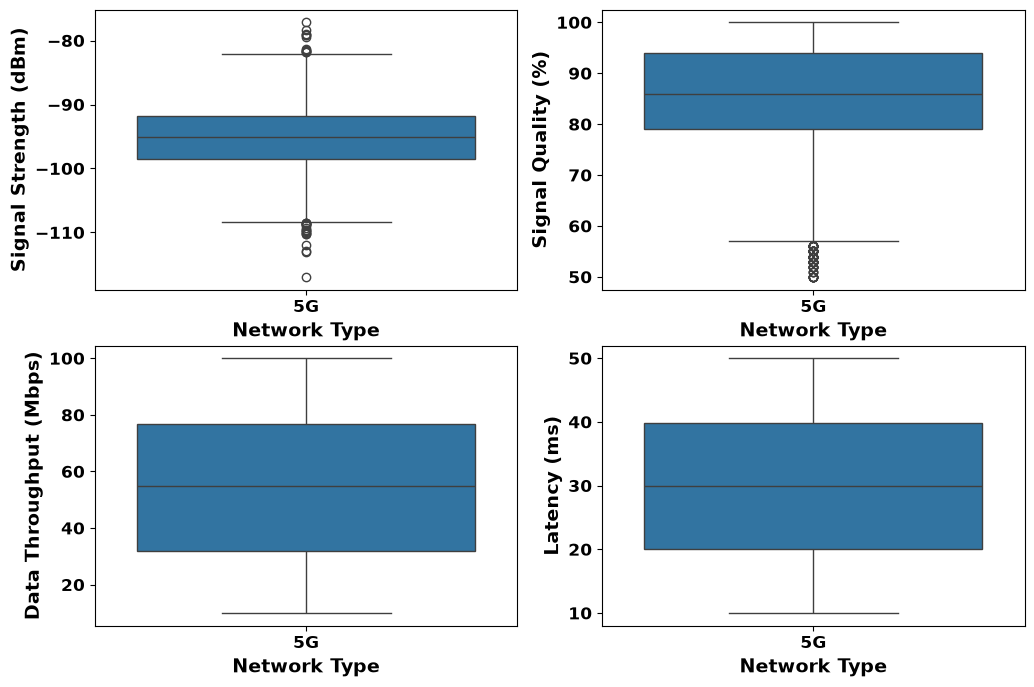

In [208]:
# Boxplots for KPIs

df_5G = df[df[NETWORK]=="5G"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes_flat = axes.flatten()

sns.boxplot(data=df_5G, x= df_5G[NETWORK], y= SIGNAL, hue= df_5G[NETWORK], ax= axes_flat[0])
sns.boxplot(data=df_5G, x= df_5G[NETWORK], y= SIGNAL_QUALITY, hue= df_5G[NETWORK], ax= axes_flat[1])
sns.boxplot(data=df_5G, x= df_5G[NETWORK], y= THROUGHPUT, hue= df_5G[NETWORK], ax= axes_flat[2])
sns.boxplot(data=df_5G, x= df_5G[NETWORK], y= LATENCY, hue= df_5G[NETWORK], ax= axes_flat[3])



In [209]:
# df_5G.head()

In [210]:
# QoE dataframe

df_qoe = df[df[NETWORK].isin(ORDER)].copy()

In [211]:
#df_qoe.head()

In [212]:
# Normalizing data for Qality of Experience

def minmax_normalize(series, higher_is_better=True):
    """
    Normalized 0–1.
    If higher_is_better=False, lower raw values receive higher normalized scores.
    """
    series = pd.to_numeric(series, errors="coerce")

    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series(1.0, index=series.index)

    normalized = (series - min_val) / (max_val - min_val)

    if not higher_is_better:
        normalized = 1 - normalized

    return normalized

In [213]:
# Normalize KPIs

df_qoe["norm_signal"] = minmax_normalize(
    df_qoe[SIGNAL],
    higher_is_better=True
)

df_qoe["norm_signal_quality"] = minmax_normalize(
    df_qoe[SIGNAL_QUALITY],
    higher_is_better=True
)

df_qoe["norm_throughput"] = minmax_normalize(
    df_qoe[THROUGHPUT],
    higher_is_better=True
)

df_qoe["norm_latency"] = minmax_normalize(
    df_qoe[LATENCY],
    higher_is_better=False
)

df_qoe["norm_latency"] = minmax_normalize(
    df_qoe[LATENCY],
    higher_is_better=False
)

# Radio Quality Index
df_qoe["RQI"] = (
    0.6 * df_qoe["norm_signal_quality"] +
    0.4 * df_qoe["norm_signal"]
)

# Service Performance Index
df_qoe["SPI"] = (
    0.6 * df_qoe["norm_throughput"] +
    0.4 * df_qoe["norm_latency"]
)

# Overall QoE Score
df_qoe["QoE"] = (
    0.6 * df_qoe["SPI"] +
    0.4 * df_qoe["RQI"]
)

# Optional: convert to 0–100 scale
QOE_PERCENT = "QoE_percent"
QOE_RATING = "QoE_rating"

df_qoe[QOE_PERCENT] = df_qoe["QoE"] * 100

#df_qoe

In [214]:
# Definition of QoE Ratings

def classify_qoe(score):
    if score >= 90:
        return "Excellent"
    elif score >= 80:
        return "Very Good"
    elif score >= 70:
        return "Good"
    elif score >= 60:
        return "Fair"
    else:
        return "Poor"


df_qoe["QoE_rating"] = df_qoe["QoE_percent"].apply(classify_qoe)

# Preview result
#df_qoe.head()

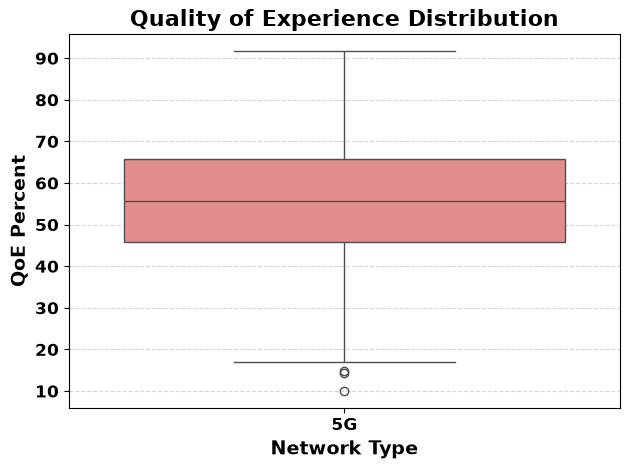

In [215]:
# Distribution of QoE % values
ax = sns.boxplot(
    data = df_qoe,
    x = df[NETWORK],
    y = QOE_PERCENT,
    hue = df[NETWORK],
    order = ORDER,
    palette= PALETTE,
    legend=False,
)

# QOE_METRICS = [QOE_PERCENT]

# boxplot_stats = compute_boxplot_stats(
#     data=df_qoe,
#     group_col=NETWORK,
#     metrics= QOE_METRICS
# )

plt.title(f"Quality of Experience Distribution")
plt.xlabel("Network Type")
plt.ylabel("QoE Percent")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


QOE HEATMAPS

In [216]:
# Map QoE ratings to numerical values

qoe_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very Good": 4,
    "Excellent": 5
}

# # Custom Ericsson-style color progression
# cmap = ListedColormap([
#     "#d73027",   # Poor - Red
#     "#fc8d59",   # Fair - Orange
#     "#fee08b",   # Good - Yellow
#     "#91cf60",   # Very Good - Light Green
#     "#1a9850"    # Excellent - Green
# ])

cmap = ListedColormap([
    "#d73027",   # Poor - Red
    "#ffffff",   # Fair - Orange
    "#fffffff8",   # Good - Yellow
    "#ffffff",   # Very Good - Light Green
    "#FFFFFF"    # Excellent - Green
])

 # Convert to a single-column matrix
columns_to_extract = [LONGITUDE, LATITUDE, SIGNAL, SIGNAL_QUALITY, THROUGHPUT, LATENCY, QOE_RATING]
df_qoe_5G = df_qoe.loc[df_qoe[NETWORK] == "5G", columns_to_extract].copy() #uses less memory

df_qoe_5G["QoE_numeric"] = df_qoe_5G[QOE_RATING].map(qoe_map)

# 3G Heatmap for QoE
heatmap_data = df_qoe_5G[["QoE_numeric"]]



In [217]:
# heatmap_data.head()

In [218]:
# df_qoe_5G.head()

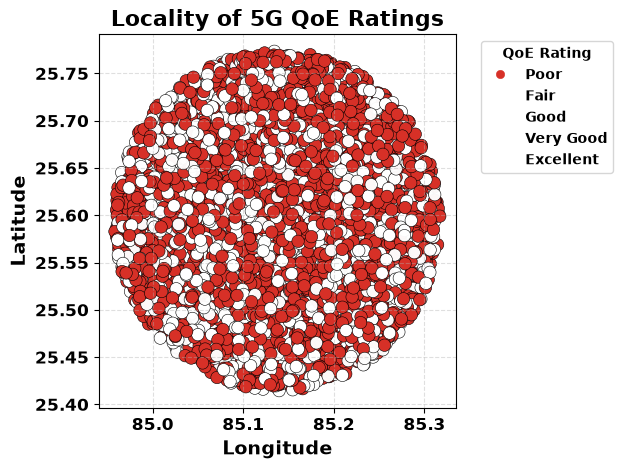

In [219]:
# Locality of 5G QoE ratings

# plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x = df_qoe_5G[LONGITUDE],
    y = df_qoe_5G[LATITUDE],
    s=80,
    c = heatmap_data["QoE_numeric"],
    cmap = cmap,
    edgecolor="black",
    linewidth=0.4,
    label= "RATING"
)

# cbar = plt.colorbar(scatter)
# cbar.set_label(f"QoE Rating")

plt.title(f"Locality of 5G QoE Ratings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=["Poor", "Fair", "Good", "Very Good", "Excellent"], title="QoE Rating", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

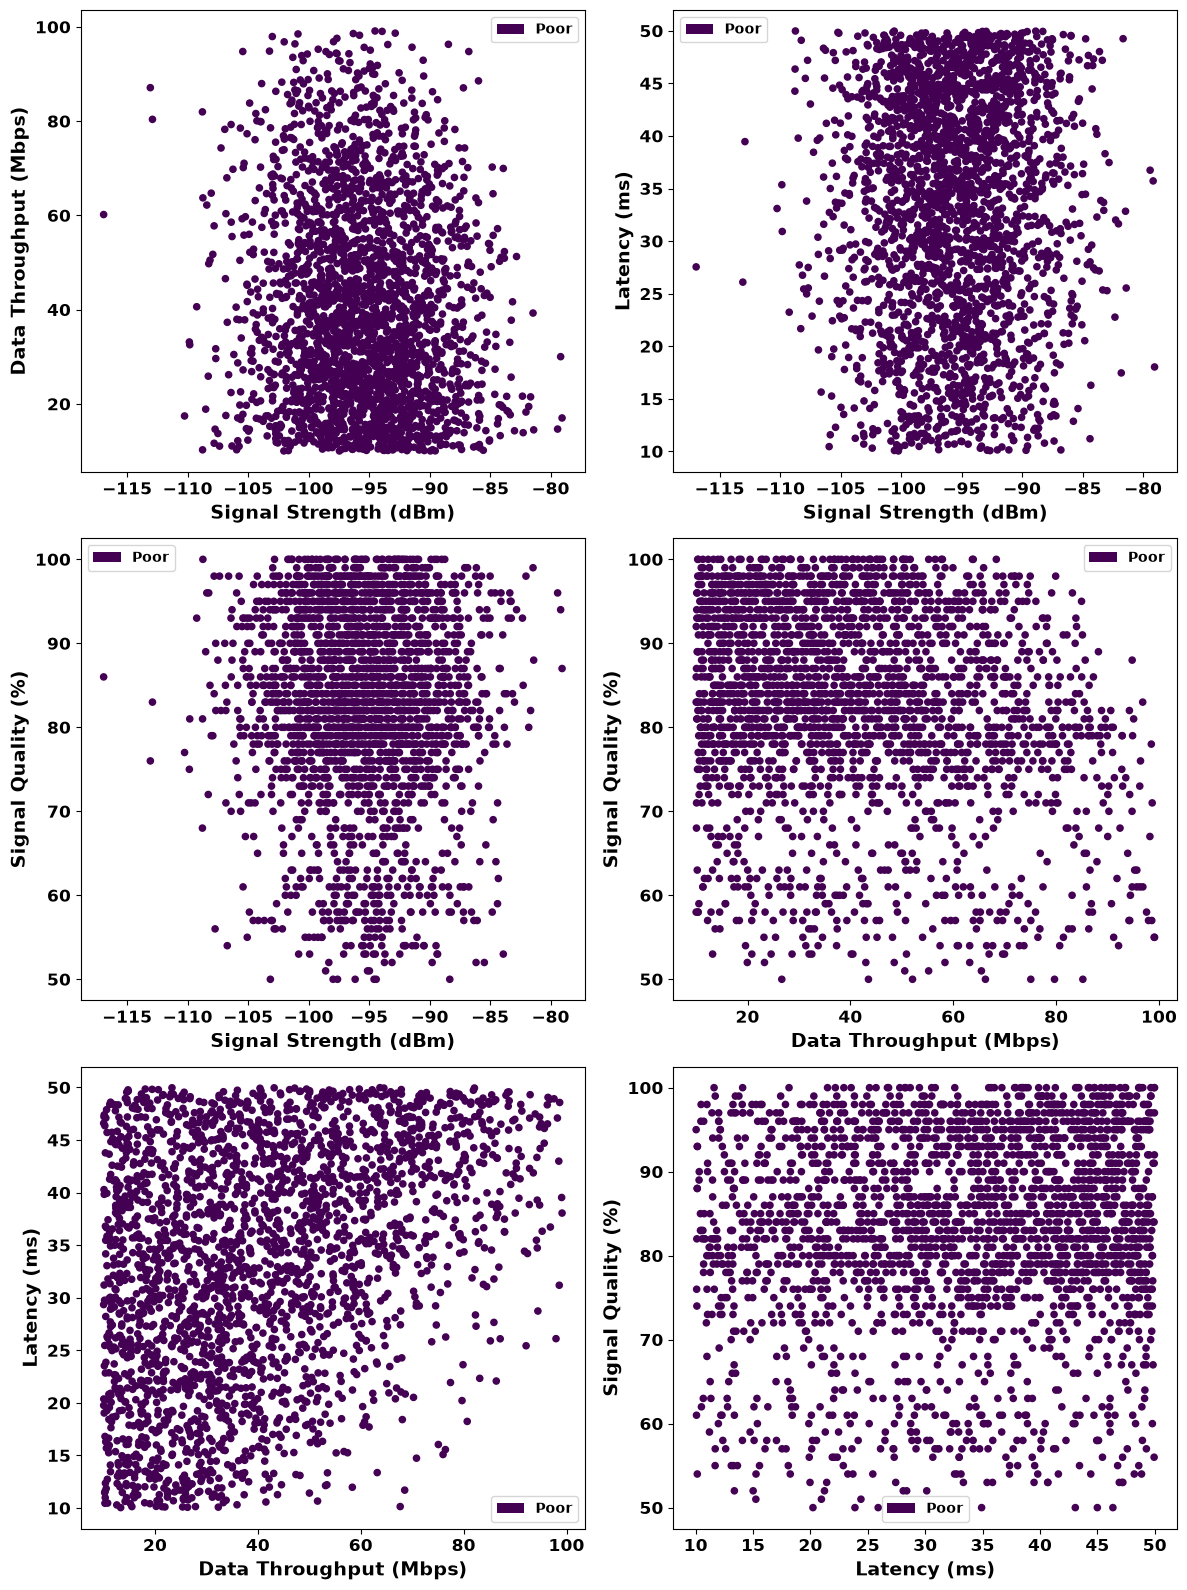

In [220]:
Poor_5G = df_qoe_5G[df_qoe_5G[QOE_RATING] == "Poor"]

plt.rcParams['axes.labelsize'] = 14       # Font size for X and Y labels
plt.rcParams['axes.labelweight'] = 'bold' # Bold X and Y labels
plt.rcParams['axes.titlesize'] = 16       # Font size for subplot titles
plt.rcParams['axes.titleweight'] = 'bold' # Bold subplot titles
plt.rcParams['xtick.labelsize'] = 12      # Font size for X tick values
plt.rcParams['ytick.labelsize'] = 12      # Font size for Y tick values

plt.rcParams['font.weight'] = 'bold'

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 16))

axes_flat = axes.flatten()

Poor_5G.plot.scatter(x=SIGNAL, y=THROUGHPUT, c=QOE_RATING, ax=axes_flat[0])
Poor_5G.plot.scatter(x=SIGNAL, y=LATENCY, c=QOE_RATING, ax=axes_flat[1])
Poor_5G.plot.scatter(x=SIGNAL, y=SIGNAL_QUALITY, c=QOE_RATING, ax=axes_flat[2])
Poor_5G.plot.scatter(x=THROUGHPUT, y=SIGNAL_QUALITY, c=QOE_RATING, ax=axes_flat[3])
Poor_5G.plot.scatter(x=THROUGHPUT, y=LATENCY, c=QOE_RATING, ax=axes_flat[4])
Poor_5G.plot.scatter(x=LATENCY, y=SIGNAL_QUALITY, c=QOE_RATING, ax=axes_flat[5])

plt.tight_layout()
plt.show()


In [221]:
# Poor_5G.head()

                              Signal Strength (dBm)  Signal Quality (%)  \
Signal Strength (dBm)                      1.000000           -0.007440   
Signal Quality (%)                        -0.007440            1.000000   
Data Throughput (Mbps)                    -0.025197            0.007013   
Latency (ms)                              -0.007172            0.004619   
BB60C Measurement (dBm)                    0.862907            0.002834   
srsRAN Measurement (dBm)                   0.959976           -0.004993   
BladeRFxA9 Measurement (dBm)               0.944718           -0.007596   

                              Data Throughput (Mbps)  Latency (ms)  \
Signal Strength (dBm)                      -0.025197     -0.007172   
Signal Quality (%)                          0.007013      0.004619   
Data Throughput (Mbps)                      1.000000      0.009929   
Latency (ms)                                0.009929      1.000000   
BB60C Measurement (dBm)                    -0.035

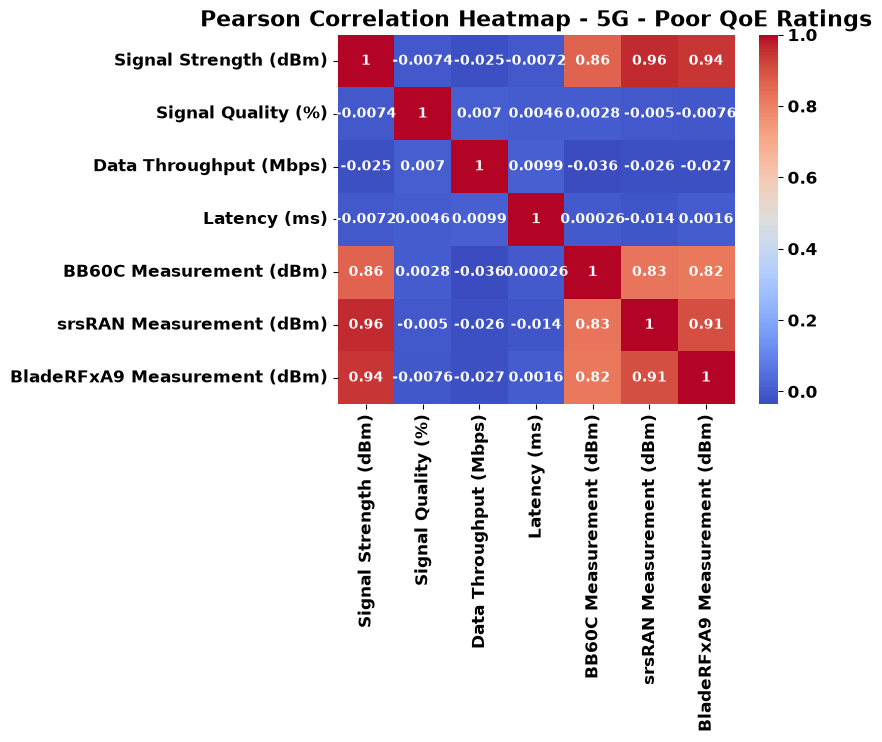

In [222]:
pearson_corr =df.loc[df[NETWORK]=="5G", [SIGNAL, SIGNAL_QUALITY, THROUGHPUT, LATENCY, BB60C, SRSRAN, BLADERF]].corr(method='pearson')
print(pearson_corr)

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap - 5G - Poor QoE Ratings")
plt.show()